In [57]:
# Core libraries for data handling, the neural network and evaluation
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

torch.manual_seed(42)   # fixes randomness in PyTorch so results are reproducible
np.random.seed(42)      # fixes randomness in numpy/sklearn splits too

## Part 1: Train the Model

In [58]:
df = pd.read_csv('/content/ev_battery_failure_dataset.csv')  # load the raw sensor dataset
df.head()  # quick look at the first few rows

,vehicle_id,vehicle_brand,vehicle_model,vehicle_type,manufacturing_year,battery_manufacturer,battery_chemistry,battery_capacity_kwh,drive_type,odometer_km,...,sensor_fault_count,BMS_warning_count,abnormal_voltage_events,battery_stress_index,aging_score,thermal_health_score,charging_quality_score,driving_stress_score,predicted_remaining_life_cycles,battery_failure
0,EV100000,Nissan,Leaf,SUV,2019.0,CATL,LMO,82.54,RWD,98163.0,...,2.0,3.0,0.0,0.0,53.5,66.0,65.2,0.0,401.0,0.0
1,EV100001,Audi,e-tron,Sedan,2018.0,Samsung SDI,NaN,64.17,AWD,113600.0,...,0.0,3.0,0.0,51.0,38.8,67.8,46.3,40.9,1094.0,0.0
2,EV100002,Toyota,bZ4X,Van,2018.0,Guoxuan,NMC,90.92,RWD,242253.0,...,4.0,1.0,0.0,36.2,66.1,48.6,0.0,6.5,645.0,0.0
3,EV100003,Volkswagen,ID.3,Hatchback,2022.0,CATL,NMC,47.35,AWD,83700.0,...,0.0,3.0,1.0,23.4,32.5,58.2,NaN,NaN,867.0,0.0
4,EV100004,Tesla,Model X,Crossover,2015.0,BYD Battery,NMC,68.04,FWD,88784.0,...,3.0,2.0,1.0,51.2,45.4,51.0,NaN,100.0,1090.0,0.0


In [59]:
df['battery_failure'].value_counts()
# Check how many "healthy" (0) vs "failure" (1) rows exist.
# This dataset is imbalanced -- most batteries are healthy, only a small
# fraction failed. We'll handle this later so the model doesn't just learn
# to always predict "healthy".

,count
battery_failure,
0.0,7335
1.0,810


In [60]:
# We're keeping only 6 out of 70 raw columns -- each one represents a
# different, non-overlapping signal of battery health:
#   state_of_health       -> overall degradation
#   cell_voltage_std       -> voltage imbalance across cells (early warning sign)
#   charge_efficiency      -> how efficiently the battery is charging
#   cycle_count             -> usage / wear
#   internal_resistance    -> physical degradation indicator
#   thermal_runaway_risk    -> precursor to the most dangerous failure mode

features = [
    'state_of_health',
    'cell_voltage_std',
    'charge_efficiency',
    'cycle_count',
    'internal_resistance',
    'thermal_runaway_risk'
]

df_selected = df[features + ['battery_failure']].copy()
df_selected.head()

,state_of_health,cell_voltage_std,charge_efficiency,cycle_count,internal_resistance,thermal_runaway_risk,battery_failure
0,72.93,0.01829,94.63,250.0,0.6585,48.7,0.0
1,86.71,0.01518,95.16,256.0,0.5206,48.6,0.0
2,72.17,NaN,92.21,556.0,0.6135,53.2,0.0
3,NaN,0.01518,94.26,353.0,0.4144,53.6,0.0
4,86.17,0.02111,96.60,287.0,0.5663,62.1,0.0


In [61]:
# Each feature is missing roughly 4-5% of its values.
# We fill gaps with the median instead of dropping rows, so we don't
# throw away usable data. Median is used instead of mean since it's
# less affected by outliers.
for col in features:
    df_selected[col] = df_selected[col].fillna(df_selected[col].median())

df_selected.isnull().sum()  # confirm no missing values remain

,0
state_of_health,0
cell_voltage_std,0
charge_efficiency,0
cycle_count,0
internal_resistance,0
thermal_runaway_risk,0
battery_failure,1


In [62]:
print("Rows before:", len(df_selected))

Rows before: 8146


In [63]:
df_selected['battery_failure'] = pd.to_numeric(df_selected['battery_failure'], errors='coerce')
df_selected.dropna(subset=['battery_failure'], inplace=True)
X = df_selected[features].values                      # inputs the model will learn from
y = df_selected['battery_failure'].values.reshape(-1, 1)  # what we're trying to predict

In [64]:
# stratify=y keeps the same healthy/failure ratio in both the training
# and test sets, since the classes are imbalanced.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (6516, 6) Test: (1629, 6)


In [65]:
# Neural networks train better when all features are on a similar scale.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # learn the scale from training data only
X_test_scaled = scaler.transform(X_test)        # apply that same scale to test data

In [66]:
# Convert everything into PyTorch tensors, the format the model needs.
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)

In [67]:
# Since failures are rare, we tell the loss function to weigh mistakes on
# the failure class more heavily -- otherwise the model could just predict
# "healthy" every time and still look accurate.
num_healthy = (y_train == 0).sum()
num_failure = (y_train == 1).sum()
pos_weight = torch.tensor([num_healthy / num_failure], dtype=torch.float32)

print("pos_weight:", pos_weight.item())

pos_weight: 9.05555534362793


In [68]:
# A simple feedforward neural network: 6 inputs -> 16 -> 8 -> 1 output.
class BatteryFailureClassifier(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 1)
            # no sigmoid here -- BCEWithLogitsLoss applies it internally,
            # which is more numerically stable than doing it manually
        )

    def forward(self, x):
        return self.net(x)

model = BatteryFailureClassifier(input_dim=X_train_t.shape[1])
print(model)

BatteryFailureClassifier(
  (net): Sequential(
    (0): Linear(in_features=6, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=1, bias=True)
  )
)


In [69]:
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)  # binary classification loss, weighted for imbalance
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)  # Adam: a reliable default optimizer

In [70]:
epochs = 100
train_losses = []  # track loss per epoch so we can plot it afterward

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()      # clear gradients from the previous step

    logits = model(X_train_t)  # forward pass: raw model output (before sigmoid)
    loss = criterion(logits, y_train_t)

    loss.backward()            # backward pass: compute gradients
    optimizer.step()           # update model weights

    train_losses.append(loss.item())

    if (epoch + 1) % 20 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

Epoch [20/100], Loss: 0.8045
Epoch [40/100], Loss: 0.4732
Epoch [60/100], Loss: 0.4467
Epoch [80/100], Loss: 0.4368
Epoch [100/100], Loss: 0.4335


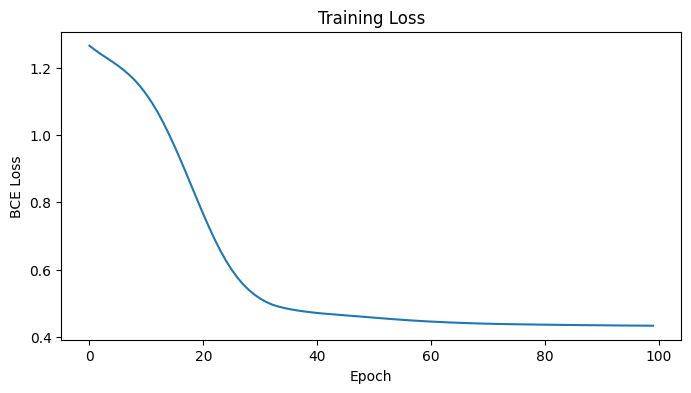

In [71]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("BCE Loss")
plt.title("Training Loss")
plt.show()
# if the line flattens out toward the end, the model has mostly finished learning

In [72]:
model.eval()  # switch to evaluation mode (disables training-only behavior)
with torch.no_grad():  # no need to track gradients when just predicting
    test_logits = model(X_test_t)
    test_probs = torch.sigmoid(test_logits).numpy()  # convert raw logits into 0-1 probabilities

y_pred = (test_probs >= 0.5).astype(int)  # turn probability into a Healthy/Failure label
y_true = y_test

acc = accuracy_score(y_true, y_pred)
print(f"Accuracy: {acc:.4f}\n")

print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=['Healthy', 'Failure']))
# NOTE: "recall" on the Failure class matters more than overall accuracy here --
# a missed failure (false negative) means a stranded driver, which is far more
# costly than an unnecessary service visit (false positive).

Accuracy: 0.8846

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.99      0.88      0.93      1467
     Failure       0.46      0.93      0.62       162

    accuracy                           0.88      1629
   macro avg       0.73      0.91      0.77      1629
weighted avg       0.94      0.88      0.90      1629



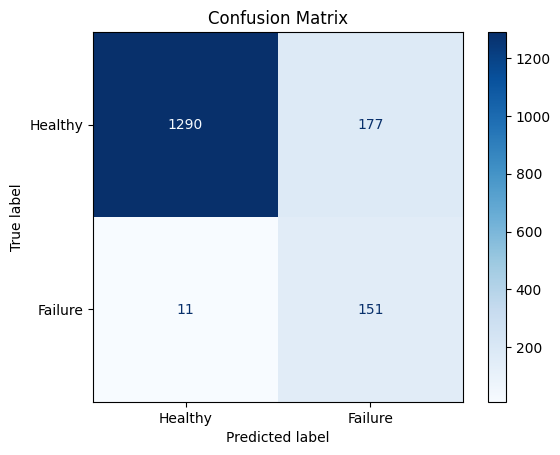

In [73]:
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Healthy', 'Failure'])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

## Part 2: Package for Deployment

The cells below save the model and write out every file needed to run it as a standalone web app.

In [74]:
import os

# Set up the folder structure the deployed app will live in.
project_root = "ev_battery_deploy"
folders = [
    f"{project_root}/app",
    f"{project_root}/app/templates",
    f"{project_root}/models",
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Project structure created.")

Project structure created.


In [75]:
import joblib

# Save the trained model's weights (not the whole object -- just what it learned).
torch.save(model.state_dict(), f"{project_root}/models/battery_model.pth")

# Save the scaler too -- the deployed app must scale new input the exact same way.
joblib.dump(scaler, f"{project_root}/models/scaler.pkl")

print("Model and scaler saved.")

Model and scaler saved.


In [76]:
%%writefile ev_battery_deploy/app/model.py
# This file recreates the model architecture and loads the saved weights,
# so the deployed app can make predictions without needing to retrain.

import torch
import torch.nn as nn
import joblib
import os

BASE_DIR = os.path.dirname(os.path.dirname(os.path.abspath(__file__)))
MODELS_DIR = os.path.join(BASE_DIR, "models")


class BatteryFailureClassifier(nn.Module):
    # Must match the training architecture exactly, or the saved weights won't load correctly.
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 1)
        )

    def forward(self, x):
        return self.net(x)


def load_artifacts():
    # Loads the scaler and the trained model weights from disk.
    scaler = joblib.load(os.path.join(MODELS_DIR, "scaler.pkl"))

    input_dim = scaler.mean_.shape[0]  # infer number of features from the scaler
    model = BatteryFailureClassifier(input_dim=input_dim)
    model.load_state_dict(torch.load(
        os.path.join(MODELS_DIR, "battery_model.pth"),
        map_location=torch.device("cpu"),
        weights_only=True
    ))
    model.eval()  # set to evaluation mode

    return model, scaler

Overwriting ev_battery_deploy/app/model.py


In [77]:
%%writefile ev_battery_deploy/app/main.py
# This is the actual web API. It loads the model once at startup, then
# exposes endpoints for making predictions.

import numpy as np
import torch
from fastapi import FastAPI, Request, Form
from fastapi.responses import HTMLResponse
from fastapi.templating import Jinja2Templates
from pydantic import BaseModel

from app.model import load_artifacts

app = FastAPI(title="EV Battery Failure Predictor")
templates = Jinja2Templates(directory="app/templates")

model, scaler = load_artifacts()  # load once when the app starts, not per-request

# Must match the exact order of features used during training.
FEATURE_ORDER = [
    "state_of_health", "cell_voltage_std", "charge_efficiency",
    "cycle_count", "internal_resistance", "thermal_runaway_risk"
]


class PredictRequest(BaseModel):
    # Defines what a valid JSON request to /predict must look like.
    state_of_health: float
    cell_voltage_std: float
    charge_efficiency: float
    cycle_count: float
    internal_resistance: float
    thermal_runaway_risk: float


def predict(features: dict):
    # Shared prediction logic used by both the API and the web form.
    x = np.array([[features[f] for f in FEATURE_ORDER]])
    x_scaled = scaler.transform(x)          # scale exactly like training data was scaled
    x_tensor = torch.tensor(x_scaled, dtype=torch.float32)

    with torch.no_grad():
        logit = model(x_tensor)
        prob = torch.sigmoid(logit).item()  # convert raw output into a 0-1 probability

    pred_class = "Failure" if prob >= 0.5 else "Healthy"
    return pred_class, prob


# --- JSON API endpoint (for other programs to call) ---
@app.post("/predict")
def predict_api(payload: PredictRequest):
    pred_class, prob = predict(payload.dict())
    return {"prediction": pred_class, "probability": round(prob, 4)}


# --- Simple web form (for a human to test in a browser) ---
@app.get("/", response_class=HTMLResponse)
def form_get(request: Request):
    return templates.TemplateResponse("index.html", {"request": request, "result": None})


@app.post("/", response_class=HTMLResponse)
def form_post(
    request: Request,
    state_of_health: float = Form(...),
    cell_voltage_std: float = Form(...),
    charge_efficiency: float = Form(...),
    cycle_count: float = Form(...),
    internal_resistance: float = Form(...),
    thermal_runaway_risk: float = Form(...),
):
    features = {
        "state_of_health": state_of_health,
        "cell_voltage_std": cell_voltage_std,
        "charge_efficiency": charge_efficiency,
        "cycle_count": cycle_count,
        "internal_resistance": internal_resistance,
        "thermal_runaway_risk": thermal_runaway_risk,
    }
    pred_class, prob = predict(features)
    result = {"prediction": pred_class, "probability": f"{prob:.4f}"}
    return templates.TemplateResponse("index.html", {"request": request, "result": result})


# Railway (and most hosts) ping this to check the app is alive.
@app.get("/health")
def health():
    return {"status": "ok"}

Overwriting ev_battery_deploy/app/main.py


In [78]:
%%writefile ev_battery_deploy/app/templates/index.html
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <title>EV Battery Failure Predictor</title>
    <style>
        body { font-family: Arial, sans-serif; max-width: 480px; margin: 40px auto; padding: 0 20px; }
        h1 { font-size: 1.4rem; }
        label { display: block; margin-top: 12px; font-weight: bold; }
        input { width: 100%; padding: 8px; margin-top: 4px; box-sizing: border-box; }
        button { margin-top: 20px; padding: 10px 16px; background: #2563eb; color: white; border: none; border-radius: 4px; cursor: pointer; }
        button:hover { background: #1d4ed8; }
        .result { margin-top: 20px; padding: 12px; border-radius: 4px; }
        .healthy { background: #f0fdf4; border: 1px solid #86efac; }
        .failure { background: #fef2f2; border: 1px solid #fca5a5; }
    </style>
</head>
<body>
    <h1>EV Battery Failure Predictor</h1>
    <form method="post" action="/">
        <label>State of Health (%)</label>
        <input type="number" step="0.01" name="state_of_health" required>

        <label>Cell Voltage Std</label>
        <input type="number" step="0.01" name="cell_voltage_std" required>

        <label>Charge Efficiency (%)</label>
        <input type="number" step="0.01" name="charge_efficiency" required>

        <label>Cycle Count</label>
        <input type="number" step="1" name="cycle_count" required>

        <label>Internal Resistance</label>
        <input type="number" step="0.001" name="internal_resistance" required>

        <label>Thermal Runaway Risk</label>
        <input type="number" step="0.01" name="thermal_runaway_risk" required>

        <button type="submit">Predict</button>
    </form>

    {% if result %}
    <div class="result {{ 'failure' if result.prediction == 'Failure' else 'healthy' }}">
        <strong>Prediction:</strong> {{ result.prediction }}<br>
        <strong>Probability of Failure:</strong> {{ result.probability }}
    </div>
    {% endif %}
</body>
</html>

Overwriting ev_battery_deploy/app/templates/index.html


In [79]:
%%writefile ev_battery_deploy/app/__init__.py

Overwriting ev_battery_deploy/app/__init__.py


In [80]:
%%writefile ev_battery_deploy/requirements.txt
fastapi==0.115.0
uvicorn[standard]==0.30.6
torch==2.4.1
scikit-learn==1.6.1
joblib==1.4.2
jinja2==3.1.4
python-multipart==0.0.9
numpy==1.26.4

Overwriting ev_battery_deploy/requirements.txt


In [81]:
%%writefile ev_battery_deploy/Dockerfile
FROM python:3.11-slim

WORKDIR /code

COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

COPY app ./app
COPY models ./models

# ${PORT:-8000} lets Railway assign its own port at runtime; defaults to 8000 locally
CMD ["sh", "-c", "uvicorn app.main:app --host 0.0.0.0 --port ${PORT:-8000}"]

Overwriting ev_battery_deploy/Dockerfile


In [82]:
%%writefile ev_battery_deploy/.dockerignore
__pycache__
*.pyc
.git
.gitignore
.ipynb_checkpoints
*.ipynb
venv/
.env

Overwriting ev_battery_deploy/.dockerignore


In [83]:
%%writefile ev_battery_deploy/.gitignore
__pycache__/
*.pyc
.ipynb_checkpoints/
venv/
.env
.DS_Store

Overwriting ev_battery_deploy/.gitignore


In [84]:
%%writefile ev_battery_deploy/railway.json
{
  "$schema": "https://railway.app/railway.schema.json",
  "build": {
    "builder": "DOCKERFILE",
    "dockerfilePath": "Dockerfile"
  },
  "deploy": {
    "restartPolicyType": "ON_FAILURE"
  }
}

Overwriting ev_battery_deploy/railway.json


In [85]:
%%writefile ev_battery_deploy/README.md
# EV Battery Failure Predictor

A PyTorch neural network classifier that predicts whether an EV battery is
healthy or heading toward failure, served with FastAPI and deployed via Docker on Railway.

## Features used
- state_of_health (%)
- cell_voltage_std
- charge_efficiency (%)
- cycle_count
- internal_resistance
- thermal_runaway_risk

## Run locally
```bash
pip install -r requirements.txt
uvicorn app.main:app --reload
```
Visit http://localhost:8000

## Run with Docker
```bash
docker build -t ev-battery-predictor .
docker run -p 8000:8000 ev-battery-predictor
```
Visit http://localhost:8000

## API
POST /predict
```json
{
  "state_of_health": 68.0,
  "cell_voltage_std": 6.2,
  "charge_efficiency": 78.5,
  "cycle_count": 950,
  "internal_resistance": 0.85,
  "thermal_runaway_risk": 74.0
}
```

## Live Deployment
[Add your Railway deployment link here]

Overwriting ev_battery_deploy/README.md


In [86]:
# Confirm every file landed where expected before pushing to GitHub.
for root, dirs, files in os.walk(project_root):
    dirs[:] = [d for d in dirs if d not in ("__pycache__",)]
    level = root.replace(project_root, "").count(os.sep)
    indent = " " * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    for f in files:
        print(f"{indent}  {f}")

ev_battery_deploy/
  railway.json
  requirements.txt
  README.md
  Dockerfile
  .gitignore
  .dockerignore
  models/
    scaler.pkl
    battery_model.pth
  app/
    main.py
    model.py
    __init__.py
    templates/
      index.html


In [87]:
import shutil
shutil.make_archive('ev_battery_deploy', 'zip', 'ev_battery_deploy')

'/content/ev_battery_deploy.zip'